# IMPORT LIBRARY

In [1345]:
import pandas as pd
import numpy as np
import random
from collections import Counter
import copy
import matplotlib.pyplot as plt

# PARAMETER 

In [1346]:
POPULASI = 50
GENERASI = 500

PROBABILITAS_CROSSOVER = 0.7
PROBABILITAS_MUTASI = 0.35
BIAS_CROSSOVER = 0.85
BIAS_MUTASI = 0.85

VIOLATION_COST = 100
TOURNAMENT_SIZE = 10

# DATASET

In [1347]:
guru_df = pd.read_csv('../dataset/guru.csv')
kelas_df = pd.read_csv('../dataset/kelas.csv')
mapel_df = pd.read_csv('../dataset/mapel.csv')
relasi_guru_mapel_df = pd.read_csv('../dataset/relasi_guru_mapel.csv')
slot_df = pd.read_csv('../dataset/slot.csv')

# RELASI

In [1348]:
join = (
    relasi_guru_mapel_df
    .merge(guru_df, on="guru_id", how="left")
    .merge(mapel_df, on="mapel_id", how="left")
)

In [1349]:
join["total"] = join.groupby("guru_id")["durasi"].transform("sum")

In [1350]:
mapping_hari = {
    "Senin" : 1,
    "Selasa" : 2,
    "Rabu" : 3,
    "Kamis" : 4,
    "Jumat" : 5
}

In [1351]:
relasi = join[[
    "guru_id", "mapel_id", "jam_per_minggu", "tingkatan", 
    "durasi", "total", "MGMP"
]].copy()

In [1352]:
relasi["MGMP"] = relasi["MGMP"]. map(mapping_hari)

In [1353]:
mapel_jam = dict(zip(mapel_df["mapel_id"], mapel_df["jam_per_minggu"]))

In [1354]:
slot_per_hari = {
    1:8,
    2:8,
    3:8,
    4:7,
    5:5
}

# DICTIONARY

In [1355]:
total_kelas = kelas_df["kelas_id"].count()

In [1356]:
batas_siang = {0: 5, 1: 5, 2: 4, 3: 5, 4: 4}
batas_mgmp = {0: 2, 1: 2, 2: 2, 3: 2, 4: 1}

In [1357]:
guru_by_mapel = (
    relasi
    .groupby(["mapel_id", "tingkatan"])["guru_id"]
    .apply(list)
    .to_dict()
)

In [1358]:
MAPEL_LIST = list(range(1, 14))

# INISIALISASI INDIVIDU

In [1359]:
def individu_construct(slot_per_hari, total_kelas, guru_by_mapel, relasi):

    mapel_id = list(range(1, 14))     # 13 mapel
    tingkatan = relasi["tingkatan"].iloc[0]

    # preprocess guru per mapel
    guru_mapel_list = {
        m: guru_by_mapel.get((m, tingkatan), [])
        for m in mapel_id
    }

    individu = []

    for _ in range(total_kelas):

        kelas = []

        # ===== GEN MAPEL PER HARI =====
        for hari in sorted(slot_per_hari.keys()):  # 1..5
            jumlah_slot = slot_per_hari[hari]
            gen_hari = [random.choice(mapel_id) for _ in range(jumlah_slot)]
            kelas.append(gen_hari)

        # ===== GEN GURU (13 MAPEL) =====
        gen_guru = [
            random.choice(guru_mapel_list[m]) if guru_mapel_list[m] else 0
            for m in mapel_id
        ]

        kelas.append(gen_guru)

        individu.append(kelas)

    return individu


In [1360]:
# populasi = []
# for i in range(POPULASI):
#     individu = individu_construct(slot_per_hari, total_kelas, guru_by_mapel, relasi)
#     populasi.append(individu)


# EVALUASI

In [1361]:
def guru_bentrok(individu, VIOLATION_COST):
    pelanggaran = 0
    cost = 0

    slot_harian = individu[0][:-1]

    for hari_id, hari in enumerate(slot_harian):
        for jam_id in range(len(hari)):
            guru_used = set()

            for kelas in individu:
                mapel = kelas[hari_id][jam_id]

                if mapel == 0:
                    continue

                guru = kelas[-1][mapel - 1]

                if guru in guru_used:
                    pelanggaran += 1
                    cost += VIOLATION_COST
                else:
                    guru_used.add(guru)

    return pelanggaran, cost

In [1362]:
# for individu in populasi:
#     pelanggaran, cost = guru_bentrok(individu, VIOLATION_COST)
#     print("Pelanggaran: ", pelanggaran)
#     print("Cost: ", cost)

In [1363]:
def konfigurasi_mapel(individu, mapel_jam, VIOLATION_COST):
    pelanggaran = 0
    cost = 0

    for kelas in individu:
        slot_harian = kelas[:-1]  # senin–jumat

        mapel_hari = {}

        for hari_id, hari in enumerate(slot_harian):
            for slot_id, mapel in enumerate(hari):
                if mapel not in mapel_hari:
                    mapel_hari[mapel] = {}
                if hari_id not in mapel_hari[mapel]:
                    mapel_hari[mapel][hari_id] = []
                mapel_hari[mapel][hari_id].append(slot_id)

        # evaluasi per mapel
        for mapel_id, distribusi_hari in mapel_hari.items():
            total_jam = mapel_jam.get(mapel_id, 0)

            # rule jumlah hari
            hari_terpakai = [len(v) for v in distribusi_hari.values()]

            if total_jam in (2, 3):
                # mapel dengan 2 , 3 jam per minggu
                if len(distribusi_hari) != 1:
                    pelanggaran += 1
                    cost += VIOLATION_COST

            elif total_jam == 4:
                # mapel dengan 4 jam per minggu
                if sorted(hari_terpakai) != [2, 2]:
                    pelanggaran += 1
                    cost += VIOLATION_COST

            elif total_jam == 5:
                # mapel dengan 5 jam per minggu
                if sorted(hari_terpakai) != [2, 3]:
                    pelanggaran += 1
                    cost += VIOLATION_COST

            # mapel harus pada slot yang berdekatan pada hari yang sama
            for slot_list in distribusi_hari.values():
                if len(slot_list) > 1:
                    slot_list = sorted(slot_list)
                    for i in range(len(slot_list) - 1):
                        if slot_list[i + 1] - slot_list[i] != 1:
                            pelanggaran += 1
                            cost += VIOLATION_COST
                            break

    return pelanggaran, cost

In [1364]:
# for individu in populasi:
#     pelanggaran, cost = konfigurasi_mapel(individu, mapel_jam, VIOLATION_COST)
#     print("Pelanggaran: ", pelanggaran)
#     print("Cost: ", cost)

In [1365]:
def mapel_pjok(individu, batas_siang, VIOLATION_COST):
    pelanggaran = 0
    cost = 0

    for kelas in individu:
        slot_harian = kelas[:-1] # hari saja

        for hari_id, hari in enumerate(slot_harian):
            batas = batas_siang[hari_id]

            for slot_id, mapel in enumerate(hari):
                if mapel == 8 and slot_id > batas:
                    pelanggaran += 1
                    cost += VIOLATION_COST
                    
    return pelanggaran, cost

In [1366]:
# for individu in populasi:
#     pelanggaran, cost = mapel_pjok(individu, batas_siang, VIOLATION_COST)
#     print("Pelanggaran: ", pelanggaran)
#     print("Cost: ", cost)

In [1367]:
def durasi_guru(individu, relasi, VIOLATION_COST):
    pelanggaran = 0
    cost = 0

    # lookup (guru, mapel) -> durasi
    durasi_lookup = {
        (row.guru_id, row.mapel_id) : row.durasi
        for row in relasi.itertuples(index=False)
    }

    for kelas in individu:
        slot_harian = kelas[:-1]
        guru_mapel = kelas[-1]

    # menghitung total jam
    jam_guru_aktual = Counter()

    for hari in slot_harian:
        for mapel in hari:
            guru = guru_mapel[mapel - 1]
            jam_guru_aktual[(guru, mapel)] += 1

    for (guru, mapel), jam_aktual in jam_guru_aktual.items():
        durasi_wajib = durasi_lookup.get((guru, mapel))

        if durasi_wajib is None:
            # tidak valid di relasi.df
            pelanggaran += 1
            cost += VIOLATION_COST

        elif jam_aktual != durasi_wajib:
            pelanggaran += abs(jam_aktual - durasi_wajib)
            cost += VIOLATION_COST * abs(jam_aktual - durasi_wajib)

    return pelanggaran, cost

In [1368]:
# for individu in populasi:
#     pelanggaran, cost = durasi_guru(individu, relasi, VIOLATION_COST)
#     print("Pelanggaran: ", pelanggaran)
#     print("Cost: ", cost)

In [1369]:
def mapel_jam_per_minggu(individu, mapel_jam, VIOLATION_COST):
    pelanggaran = 0
    cost = 0

    for kelas in individu:
        slot_harian = kelas[:-1]

        semua_slot = []
        for hari in slot_harian:
            semua_slot.extend(hari)

        hitung_mapel = Counter(semua_slot)

        for mapel_id, jam_wajib in mapel_jam.items():
            jam_aktual = hitung_mapel.get(mapel_id, 0)

            if jam_aktual != jam_wajib:
                diff = abs(jam_aktual - jam_wajib)

                pelanggaran += diff
                cost += diff * VIOLATION_COST
                
    return pelanggaran, cost

In [1370]:
# for individu in populasi:
#     pelanggaran, cost = mapel_jam_per_minggu(individu, mapel_jam, VIOLATION_COST)
#     print("Pelanggaran: ", pelanggaran)
#     print("Cost: ", cost)

In [1371]:
def build_mapel_mgmp(relasi):
    return {
        row.mapel_id: row.MGMP - 1
        for row in relasi.itertuples(index=False)
        if row.MGMP is not None
    }
    
def mgmp_slot(individu, relasi, batas_mgmp, VIOLATION_COST):
    pelanggaran = 0
    cost = 0

    mapel_mgmp = build_mapel_mgmp(relasi)

    for kelas in individu:
        slot_harian = kelas[:-1]

        for hari_id, hari in enumerate(slot_harian):
            for slot_id, mapel in enumerate(hari):

                mgmp_hari = mapel_mgmp.get(mapel)

                if mgmp_hari is None:
                    continue

                if hari_id == mgmp_hari:
                    batas_slot = batas_mgmp[hari_id]

                    if slot_id > batas_slot:
                        pelanggaran += 1
                        cost += VIOLATION_COST
    return pelanggaran, cost


In [1372]:
# for individu in populasi:
#     pelanggaran, cost = mgmp_slot(individu, relasi, batas_mgmp, VIOLATION_COST)
#     print("Pelanggaran: ", pelanggaran)
#     print("Cost: ", cost)

In [1373]:
EVALUATORS = [
    (guru_bentrok,        {}),
    (konfigurasi_mapel,  {"mapel_jam": mapel_jam}),
    (mapel_pjok,         {"batas_siang": batas_siang}),
    (durasi_guru,        {"relasi": relasi}),
    (mapel_jam_per_minggu, {"mapel_jam": mapel_jam}),
    (mgmp_slot,          {"relasi": relasi, "batas_mgmp": batas_mgmp}),
]

In [1374]:
def evaluator_function(individu):
    pelanggaran_total = 0
    cost_total = 0

    for func, params in EVALUATORS:
        pelanggaran, cost = func(individu, **params, VIOLATION_COST=VIOLATION_COST)
        pelanggaran_total += pelanggaran
        cost_total += cost
    
    return pelanggaran_total, cost_total


In [1375]:
# for individu in populasi:
#     pelanggaran, cost = evaluator_function(individu)
    # print("Pelanggaran: ", pelanggaran)
    # print("Cost: ", cost)

# MASKING

In [1376]:
def mask_guru_bentrok(individu, mask):
    slot_harian = individu[0][:-1]

    for hari_id, hari in enumerate(slot_harian):
        for jam_id in range(len(hari)):

            guru_used = {}

            for k, kelas in enumerate(individu):

                mapel = kelas[hari_id][jam_id]

                if mapel == 0:
                    continue

                guru = kelas[-1][mapel - 1]

                if guru in guru_used:
                    k2 = guru_used[guru]

                    # tandai kedua slot konflik
                    mask[k][hari_id][jam_id]  = 0
                    mask[k2][hari_id][jam_id] = 0

                else:
                    guru_used[guru] = k
    return mask


In [1377]:
def mask_konfigurasi_mapel(individu, mask, mapel_jam):
    for k, kelas in enumerate(individu):
        slot_harian = kelas[:-1]  # hanya hari

        mapel_hari = {}

        # kumpulkan posisi mapel
        for hari_id, hari in enumerate(slot_harian):
            for slot_id, mapel in enumerate(hari):
                if mapel not in mapel_hari:
                    mapel_hari[mapel] = {}
                if hari_id not in mapel_hari[mapel]:
                    mapel_hari[mapel][hari_id] = []
                mapel_hari[mapel][hari_id].append(slot_id)

        # evaluasi per mapel
        for mapel_id, distribusi_hari in mapel_hari.items():
            total_jam = mapel_jam.get(mapel_id, 0)

            hari_terpakai = [len(v) for v in distribusi_hari.values()]
            pelanggaran_hari = False

            # ===== rule distribusi hari =====
            if total_jam in (2, 3):
                if len(distribusi_hari) != 1:
                    pelanggaran_hari = True

            elif total_jam == 4:
                if sorted(hari_terpakai) != [2, 2]:
                    pelanggaran_hari = True

            elif total_jam == 5:
                if sorted(hari_terpakai) != [2, 3]:
                    pelanggaran_hari = True

            # tandai semua slot mapel ini jika distribusi hari salah
            if pelanggaran_hari:
                for h, slot_list in distribusi_hari.items():
                    for s in slot_list:
                        mask[k][h][s] = 0

            # ===== rule slot harus berurutan =====
            for h, slot_list in distribusi_hari.items():
                if len(slot_list) > 1:
                    slot_list = sorted(slot_list)
                    for i in range(len(slot_list) - 1):
                        if slot_list[i + 1] - slot_list[i] != 1:
                            # tandai semua slot mapel di hari tsb
                            for s in slot_list:
                                mask[k][h][s] = 0
                            break
    return mask


In [1378]:
def mask_mapel_pjok(individu, mask, batas_siang):

    for k, kelas in enumerate(individu):
        slot_harian = kelas[:-1]

        for hari_id, hari in enumerate(slot_harian):
            batas = batas_siang[hari_id]

            for slot_id, mapel in enumerate(hari):
                if mapel == 8 and slot_id > batas:
                    mask[k][hari_id][slot_id] = 0
    return mask


In [1379]:
def mask_durasi_guru(individu, mask, relasi):
    # lookup (guru, mapel) -> durasi wajib
    durasi_lookup = {
        (row.guru_id, row.mapel_id): row.durasi
        for row in relasi.itertuples(index=False)
    }

    for k, kelas in enumerate(individu):
        slot_harian = kelas[:-1]
        guru_mapel = kelas[-1]

        # hitung jam aktual guru-mapel di kelas ini
        jam_guru_aktual = Counter()

        for hari in slot_harian:
            for mapel in hari:
                guru = guru_mapel[mapel - 1]
                jam_guru_aktual[(guru, mapel)] += 1

        # cek pelanggaran
        for (guru, mapel), jam_aktual in jam_guru_aktual.items():
            durasi_wajib = durasi_lookup.get((guru, mapel))

            if durasi_wajib is None or jam_aktual != durasi_wajib:

                # tandai semua slot mapel ini di kelas tsb
                for h, hari in enumerate(slot_harian):
                    for s, m in enumerate(hari):
                        if m == mapel:
                            mask[k][h][s] = 0
    return mask


In [1380]:
def mask_mapel_pjok(individu, mask, batas_siang):

    PJOK_ID = 8
    for k, kelas in enumerate(individu):
        slot_harian = kelas[:-1]  # hanya hari

        for hari_id, hari in enumerate(slot_harian):
            batas = batas_siang[hari_id]

            for slot_id, mapel in enumerate(hari):
                if mapel == PJOK_ID and slot_id > batas:
                    mask[k][hari_id][slot_id] = 0

    return mask


In [1381]:
def mask_mapel_jam_per_minggu(individu, mask, mapel_jam):

    for k, kelas in enumerate(individu):
        slot_harian = kelas[:-1]

        semua_posisi = {}
        semua_slot = []

        for h, hari in enumerate(slot_harian):
            for s, mapel in enumerate(hari):
                semua_slot.append(mapel)

                if mapel not in semua_posisi:
                    semua_posisi[mapel] = []
                semua_posisi[mapel].append((h, s))

        hitung_mapel = Counter(semua_slot)

        for mapel_id, jam_wajib in mapel_jam.items():
            jam_aktual = hitung_mapel.get(mapel_id, 0)

            # ===============================
            # KELEBIHAN JAM → mask slot mapel
            # ===============================
            if jam_aktual > jam_wajib:
                selisih = jam_aktual - jam_wajib

                for (h, s) in semua_posisi.get(mapel_id, [])[:selisih]:
                    mask[k][h][s] = 0

            # ===============================
            # KEKURANGAN JAM → mask slot 0
            # ===============================
            elif jam_aktual < jam_wajib:
                selisih = jam_wajib - jam_aktual

                for (h, s) in semua_posisi.get(0, [])[:selisih]:
                    mask[k][h][s] = 0

    return mask


In [1382]:
def mask_mgmp_slot(individu, mask, relasi, batas_mgmp):

    mapel_mgmp = build_mapel_mgmp(relasi)

    for k, kelas in enumerate(individu):
        slot_harian = kelas[:-1]

        for hari_id, hari in enumerate(slot_harian):
            for slot_id, mapel in enumerate(hari):

                mgmp_hari = mapel_mgmp.get(mapel)

                if mgmp_hari is None:
                    continue

                if hari_id == mgmp_hari:
                    batas_slot = batas_mgmp[hari_id]

                    if slot_id > batas_slot:
                        mask[k][hari_id][slot_id] = 0
    return mask


In [1383]:
def build_guru_mask(individu, mask, relasi):

    total_kelas = len(individu)

    for k in range(total_kelas):
        for h in range(len(individu[k]) - 1):
            for j in range(len(individu[k][h])):

                mapel = individu[k][h][j]

                rel_k = relasi.iloc[k]
                if mapel not in rel_k:
                    continue

                guru = rel_k[mapel]

                # cek bentrok
                for kk in range(total_kelas):
                    if kk == k:
                        continue

                    if h >= len(individu[kk]) - 1:
                        continue
                    if j >= len(individu[kk][h]):
                        continue

                    mapel2 = individu[kk][h][j]
                    rel_k2 = relasi.iloc[kk]

                    if mapel2 not in rel_k2:
                        continue

                    guru2 = rel_k2[mapel2]

                    if guru == guru2:
                        mask[k][h][j] = 0
                        mask[kk][h][j] = 0

    return mask


###### Main Mask

In [1384]:
def build_mask_init(individu):
    mask = []

    for kelas in individu:
        kelas_mask = []
        for hari in kelas[:-1]:
            kelas_mask.append([1] * len(hari))
        mask.append(kelas_mask)

    return mask

In [1385]:
def build_mask(individu):
    mask = build_mask_init(individu)
    
    mask_guru_bentrok(individu, mask)
    mask_konfigurasi_mapel(individu, mask, mapel_jam)
    mask_mapel_pjok(individu, mask, batas_siang)
    mask_durasi_guru(individu, mask, relasi)
    mask_mapel_jam_per_minggu(individu, mask, mapel_jam)
    mask_mgmp_slot(individu, mask, relasi, batas_mgmp)
    build_guru_mask(individu, mask, relasi)

    return mask

In [1386]:
# for individu in populasi:
#     mask = build_mask(individu)
#     print(mask)

# SELEKSI TURNAMEN

In [1387]:
def tournament_selection(populasi, fitness):
    kandidat = random.sample(list(zip(populasi, fitness)), TOURNAMENT_SIZE)
    kandidat.sort(key=lambda x: x[1])
    return kandidat[0][0]

# MULTI-POINT CROSSOVER

In [1388]:
def crossover(p1, p2, mask1):

    c1 = copy.deepcopy(p1)
    c2 = copy.deepcopy(p2)

    for k in range(len(c1)):

        if random.random() > PROBABILITAS_CROSSOVER:
            continue

        mode = random.random()

        # ===== MODE 1: MASK GUIDED SWAP (EXPLOIT) =====
        if mode < 0.5:
            for h in range(len(c1[k]) - 1):
                zero_id = np.where(np.array(mask1[k][h]) == 0)[0]

                if len(zero_id) > 0 and random.random() < BIAS_CROSSOVER:
                    for i in zero_id:
                        c1[k][h][i], c2[k][h][i] = c2[k][h][i], c1[k][h][i]

        # ===== MODE 2: DAY BLOCK SWAP =====
        elif mode < 0.7:
            h = random.randint(0, len(c1[k]) - 2)
            c1[k][h], c2[k][h] = c2[k][h], c1[k][h]

        # ===== MODE 3: RANDOM SLOT =====
        elif mode < 0.85:
            h = random.randint(0, len(c1[k]) - 2)
            i = random.randint(0, len(c1[k][h]) - 1)
            c1[k][h][i], c2[k][h][i] = c2[k][h][i], c1[k][h][i]

        # ===== MODE 4: PARTIAL WEEK SWAP =====
        else:
            days = random.sample(range(len(c1[k]) - 1), random.randint(2,3))
            for h in days:
                c1[k][h], c2[k][h] = c2[k][h], c1[k][h]

    return c1, c2


# SCRAMBLED MUTATION

In [1389]:
def mutasi(individu, mask):

    for k in range(len(individu)):
        for h in range(len(individu[k]) - 1):

            if random.random() > PROBABILITAS_MUTASI:
                continue

            hari = individu[k][h]
            hari_mask = np.array(mask[k][h])

            zero_id = np.where(hari_mask == 0)[0]
            one_id  = np.where(hari_mask == 1)[0]

            mode = random.random()

            # ===== MODE 1: MASK FOCUSED SHUFFLE =====
            if mode < 0.5 and len(zero_id) >= 2:
                if random.random() < BIAS_MUTASI:
                    vals = [hari[i] for i in zero_id]
                    random.shuffle(vals)
                    for i,v in zip(zero_id, vals):
                        hari[i] = v

            # ===== MODE 2: CONFLICT SWAP =====
            elif mode < 0.75 and len(zero_id) > 0 and len(one_id) > 0:
                i = random.choice(zero_id)
                j = random.choice(one_id)
                hari[i], hari[j] = hari[j], hari[i]

            # ===== MODE 3: RANDOM RESET =====
            else:
                i = random.randint(0, len(hari) - 1)
                hari[i] = random.randint(1, 13)

    return individu


In [1390]:
def repair_operator(individu, mask):

    base_accept = 0.75
    min_accept  = 0.15

    for k in range(len(individu)):
        for h in range(len(individu[k]) - 1):

            hari = individu[k][h]
            hari_mask = np.array(mask[k][h])
            zero_id = np.where(hari_mask == 0)[0]

            if len(zero_id) < 2:
                continue

            conflict_ratio = len(zero_id) / len(hari)
            p_accept = min_accept + (base_accept - min_accept) * conflict_ratio

            i1, i2 = np.random.choice(zero_id, size=2, replace=False)

            old1, old2 = hari[i1], hari[i2]
            hari[i1], hari[i2] = hari[i2], hari[i1]

            if random.random() > p_accept:
                hari[i1], hari[i2] = old1, old2

    return individu


In [1391]:
def schedule_course(individu, k, h, j, mapel, relasi, mask):
    guru = relasi[k].get(mapel, None)

    if guru is None:
        return False

    # cek guru bentrok
    for kk in range(len(individu)):
        if kk == k:
            continue
        mapel2 = individu[kk][h][j]
        guru2 = relasi[kk].get(mapel2, None)

        if guru2 == guru:
            return False

    individu[k][h][j] = mapel
    mask[k][h][j] = 1
    return True


In [1392]:
def repair_guru_bentrok(individu, relasi, max_trial=20):

    total_kelas = len(individu)

    for k in range(total_kelas):
        for h in range(len(individu[k]) - 1):
            for j in range(len(individu[k][h])):

                mapel = individu[k][h][j]
                rel_k = relasi.iloc[k]

                if mapel not in rel_k:
                    continue

                guru = rel_k[mapel]

                konflik = []

                for kk in range(total_kelas):
                    if kk == k:
                        continue
                    if h >= len(individu[kk]) - 1:
                        continue
                    if j >= len(individu[kk][h]):
                        continue

                    mapel2 = individu[kk][h][j]
                    rel_k2 = relasi.iloc[kk]

                    if mapel2 not in rel_k2:
                        continue

                    if rel_k2[mapel2] == guru:
                        konflik.append(kk)

                if len(konflik) > 0:
                    for _ in range(max_trial):
                        new_h = random.randint(0, len(individu[k]) - 2)
                        new_j = random.randint(0, len(individu[k][new_h]) - 1)

                        mapel2 = individu[k][new_h][new_j]
                        if mapel2 not in rel_k:
                            continue

                        if rel_k[mapel2] != guru:
                            individu[k][h][j], individu[k][new_h][new_j] = \
                                individu[k][new_h][new_j], individu[k][h][j]
                            break

    return individu


In [1393]:
def guru_targeted_mutation(individu, relasi, p_mut=0.4):

    total_kelas = len(individu)

    for k in range(total_kelas):
        for h in range(len(individu[k]) - 1):
            for j in range(len(individu[k][h])):

                mapel = individu[k][h][j]
                rel_k = relasi.iloc[k]

                if mapel not in rel_k:
                    continue

                guru = rel_k[mapel]

                bentrok = []

                for kk in range(total_kelas):
                    if kk == k:
                        continue
                    if h >= len(individu[kk]) - 1:
                        continue
                    if j >= len(individu[kk][h]):
                        continue

                    mapel2 = individu[kk][h][j]
                    rel_k2 = relasi.iloc[kk]

                    if mapel2 in rel_k2 and rel_k2[mapel2] == guru:
                        bentrok.append(kk)

                if len(bentrok) > 0 and random.random() < p_mut:

                    h2 = random.randint(0, len(individu[k]) - 2)
                    j2 = random.randint(0, len(individu[k][h2]) - 1)

                    individu[k][h][j], individu[k][h2][j2] = \
                        individu[k][h2][j2], individu[k][h][j]

    return individu


In [1394]:
def resolve_conflict(individu, mask, relasi):
    individu = repair_operator(individu, mask)
    individu = repair_guru_bentrok(individu, relasi)
    return individu


In [1395]:
def avoid_conflicts(individu, mask, relasi):

    individu = repair_guru_bentrok(individu, relasi)
    individu = guru_targeted_mutation(individu, relasi)
    individu = repair_operator(individu, mask)

    return individu


# MAIN

In [1396]:
def genetic_algorithm():

    # inisialisasi
    populasi = [individu_construct(slot_per_hari, total_kelas, guru_by_mapel, relasi) for _ in range(POPULASI)]

    # eval awal
    fitness = [evaluator_function(individu) for individu in populasi]

    individu_terbaik = None
    fitness_terbaik = min(fitness)

    riwayat = []

    # Reproduksi
    for generasi in range(GENERASI):
        populasi_baru = []

        elitisme_indeks = fitness.index(min(fitness))
        elitisme = copy.deepcopy(populasi[elitisme_indeks])

        while len(populasi_baru) < POPULASI - 1:

            # seleksi
            p1 = tournament_selection(populasi, fitness)
            p2 = tournament_selection(populasi, fitness)

            # masking individu terbaik
            mask = build_mask(p1)

            c1, c2 = crossover(p1, p2, mask)

            c1 = mutasi(c1, mask)
            c2 = mutasi(c2, mask)

            c1 = resolve_conflict(c1, mask, relasi)
            c2 = resolve_conflict(c2, mask, relasi)

            c1 = avoid_conflicts(c1, mask, relasi)
            c2 = avoid_conflicts(c2, mask, relasi)
            
            
            populasi_baru.extend([c1,c2])

        populasi_baru = populasi_baru[:POPULASI - 1]
        populasi_baru.append(elitisme)

        populasi = populasi_baru
        fitness = [evaluator_function(individu) for individu in populasi]

        generasi_terbaik = min(fitness)
        riwayat.append(generasi_terbaik)

        if generasi_terbaik < fitness_terbaik:
            fitness_terbaik = generasi_terbaik
            individu_terbaik = copy.deepcopy(
                populasi[fitness.index(generasi_terbaik)]
            )

        # output

        print(f"Generasi {1 + generasi:4d} | Best: {generasi_terbaik}")
        
    return individu_terbaik, fitness_terbaik, riwayat

In [1397]:
individu_terbaik, fitness_terbaik, riwayat = genetic_algorithm()

Generasi    1 | Best: (1435, 143500)
Generasi    2 | Best: (1424, 142400)
Generasi    3 | Best: (1381, 138100)
Generasi    4 | Best: (1364, 136400)
Generasi    5 | Best: (1337, 133700)
Generasi    6 | Best: (1322, 132200)
Generasi    7 | Best: (1322, 132200)
Generasi    8 | Best: (1307, 130700)
Generasi    9 | Best: (1300, 130000)
Generasi   10 | Best: (1286, 128600)
Generasi   11 | Best: (1277, 127700)
Generasi   12 | Best: (1273, 127300)
Generasi   13 | Best: (1273, 127300)
Generasi   14 | Best: (1265, 126500)
Generasi   15 | Best: (1265, 126500)
Generasi   16 | Best: (1265, 126500)
Generasi   17 | Best: (1265, 126500)
Generasi   18 | Best: (1259, 125900)
Generasi   19 | Best: (1239, 123900)
Generasi   20 | Best: (1235, 123500)
Generasi   21 | Best: (1232, 123200)
Generasi   22 | Best: (1232, 123200)
Generasi   23 | Best: (1232, 123200)
Generasi   24 | Best: (1232, 123200)
Generasi   25 | Best: (1232, 123200)
Generasi   26 | Best: (1232, 123200)
Generasi   27 | Best: (1232, 123200)
G

KeyboardInterrupt: 

In [ ]:
print("\n==== HASIL TERBAIK ====")
print("Fitness :", fitness_terbaik)
print("Pelanggaran :", fitness_terbaik[0])
print("Cost :", fitness_terbaik[1])


==== HASIL TERBAIK ====
Fitness : (1131, 113100)
Pelanggaran : 1131
Cost : 113100


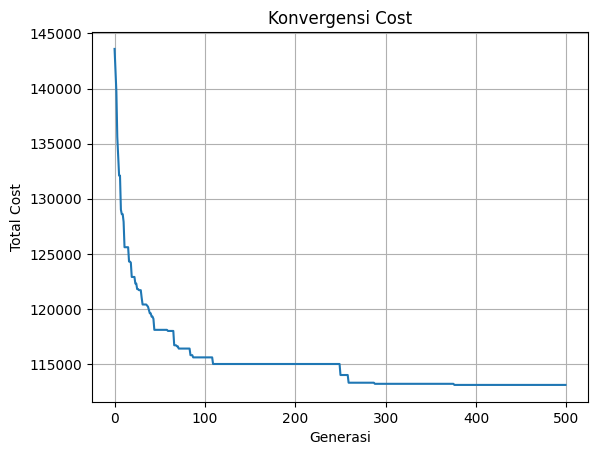

In [ ]:
plt.plot([r[1] for r in riwayat])
plt.xlabel("Generasi")
plt.ylabel("Total Cost")
plt.title("Konvergensi Cost")
plt.grid(True)
plt.show()